# Bagging - Random Forest

# 🌲 Random Forest Classifier (Кездейсоқ Орман) - Шпаргалка

> **Принципі (Bagging):** Бірнеше тәуелсіз Шешім ағаштарын (Decision Trees) кездейсоқ деректер жиынтығында жаттықтырып, олардың нәтижелерін "көпшілік дауыс беру" (majority voting) арқылы біріктіру. Бұл модельдің **артық үйренуін (overfitting)** азайтады.

---

## ⚙️ Негізгі Гиперпараметрлер (sklearn.ensemble.RandomForestClassifier)

Модельді баптауға (tuning) арналған ең маңызды параметрлер:

| Параметр | Түсіндірмесі | Әдепкі мәні (Default) | Баптау кеңесі |
| :--- | :--- | :--- | :--- |
| `n_estimators` | Ормандағы ағаштардың жалпы саны. | `100` | Деректер күрделі болса көбейтіңіз (мысалы, `200`, `500`). Модельді тұрақты етеді. |
| `criterion` | Бөліну сапасын өлшейтін функция. | `'gini'` | Әдетте `'gini'` жақсы жұмыс істейді, бірақ балама ретінде `'entropy'` немесе `'log_loss'` қолданып көруге болады. |
| `max_depth` | Әр ағаштың максималды тереңдігі. | `None` | Overfitting-ті болдырмау үшін шектеу қойыңыз (мысалы, `5`, `10`, `20`). |
| `min_samples_split` | Түйінді бөлу үшін қажетті ең аз дерек саны. | `2` | Ағаштың тым ұсақталып кетуінен сақтайды. `5` немесе `10` деп көріңіз. |
| `min_samples_leaf` | Ең соңғы жапырақта (leaf) қалуы тиіс ең аз дерек саны. | `1` | Шуды (noise) азайту үшін санын арттырыңыз (мысалы, `2`, `4`). |
| `max_features` | Бөліну кезінде қарастырылатын белгілер (features) саны. | `'sqrt'` | `'sqrt'` (түбір) немесе `'log2'` қолданылады. Ағаштардың әртүрлі болуын қамтамасыз етеді. |
| `bootstrap` | Деректерді қайтару арқылы кездейсоқ таңдау (Bootstrap). | `True` | Әрқашан `True` қалдырған жөн, себебі бұл Bagging-тің негізі. |
| `n_jobs` | Параллельді есептеу үшін қолданылатын процессор ядроларының саны. | `None` | `-1` мәнін берсеңіз, компьютердің барлық ядроларын қолданып, жылдам жұмыс істейді. |
| `random_state` | Кездейсоқтықты бекіту (нәтиже әрқашан бірдей болуы үшін). | `None` | Жобада кез келген тұрақты сан (мысалы, `42`) берген дұрыс. |

---

## 🚀 Жылдам Бастау (Quick Start)

```python
from sklearn.ensemble import RandomForestClassifier

# 1. Модельді инициализациялау
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# 2. Модельді жаттықтыру
rf_model.fit(X_train, y_train)

# 3. Болжам жасау
predictions = rf_model.predict(X_test)

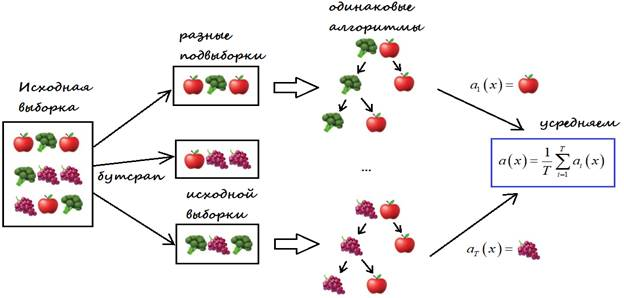

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [3]:
# 1. Деректерді жүктеу (Titanic мысалы)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# 2. Деректерді дайындау (Қарапайым түрде)
# Жынысын санға айналдырамыз (male: 0, female: 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Бос ұяшықтарды толтырамыз
df['Age'] = df['Age'].fillna(df['Age'].median())

In [19]:
# Керекті бағандарды таңдау
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [8]:
# Жаттықтыру және тест жинағына бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# 3. Random Forest моделін құру
# n_estimators - ағаштар саны
model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

In [17]:
# 4. Нәтижені тексеру
predictions = model.predict(X_test)
print(f"Дәлдік (Accuracy): {accuracy_score(y_test, predictions)*100:.2f}%")

Дәлдік (Accuracy): 78.77%
